# 01. Exploratory Data Analysis (EDA)

Este notebook realiza el Análisis Exploratorio de Datos (EDA) inicial sobre el conjunto de datos del proceso de flotación de la planta minera.

## Objetivos:
1. **Inspección de Datos:** Cargar los datos crudos, verificar dimensiones, tipos de datos y valores faltantes (nulos).
2. **Preprocesamiento Inicial:** Corregir la marca de tiempo (convertir a tipo datetime) y los separadores decimales (comas a puntos) para habilitar cálculos numéricos.
3. **Análisis de la Variable Objetivo:** Visualizar y analizar estadísticamente la distribución del porcentaje de sílice en el concentrado (`% Silica Concentrate`).
4. **Matriz de Correlación:** Examinar la correlación entre las variables de proceso para identificar dependencias y posibles casos de *target leakage*.
5. **Serie de Tiempo:** Analizar el comportamiento temporal de la calidad del concentrado a lo largo del periodo disponible (Marzo a Septiembre de 2017).

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo de visualizaciones
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Pandas version:", pd.__version__)
print("Numpy version:", np.__version__)

Pandas version: 3.0.2
Numpy version: 2.2.6


In [2]:
raw_data_path = '../data/raw/MiningProcess_Flotation_Plant_Database.csv'
print(f"Cargando datos crudos desde {raw_data_path}...")
df = pd.read_csv(raw_data_path)
print(f"Dimensiones originales del dataset: {df.shape}")

Cargando datos crudos desde ../data/raw/MiningProcess_Flotation_Plant_Database.csv...


Dimensiones originales del dataset: (737453, 24)


In [3]:
print("Limpiando y estructurando tipos de datos...")

# 1. Convertir columna de fecha
df['date'] = pd.to_datetime(df['date'])

# 2. Corregir formato de comas decimales y convertir a float todas las demás columnas
for col in df.columns:
    if col != 'date':
        df[col] = df[col].astype(str).str.replace(',', '.').astype(float)

# 3. Mostrar información básica
print("\nTipos de datos y nulos:")
print(df.info())

print("\nConteo de valores nulos:")
print(df.isna().sum())

print("\nRango de fechas:")
print(f"Inicio: {df['date'].min()} | Fin: {df['date'].max()}")

Limpiando y estructurando tipos de datos...



Tipos de datos y nulos:
<class 'pandas.DataFrame'>
RangeIndex: 737453 entries, 0 to 737452
Data columns (total 24 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   date                          737453 non-null  datetime64[us]
 1   % Iron Feed                   737453 non-null  float64       
 2   % Silica Feed                 737453 non-null  float64       
 3   Starch Flow                   737453 non-null  float64       
 4   Amina Flow                    737453 non-null  float64       
 5   Ore Pulp Flow                 737453 non-null  float64       
 6   Ore Pulp pH                   737453 non-null  float64       
 7   Ore Pulp Density              737453 non-null  float64       
 8   Flotation Column 01 Air Flow  737453 non-null  float64       
 9   Flotation Column 02 Air Flow  737453 non-null  float64       
 10  Flotation Column 03 Air Flow  737453 non-null  float64       
 11 

Estadísticas descriptivas de la variable objetivo:
count    737453.000000
mean          2.326763
std           1.125554
min           0.600000
25%           1.440000
50%           2.000000
75%           3.010000
max           5.530000
Name: % Silica Concentrate, dtype: float64


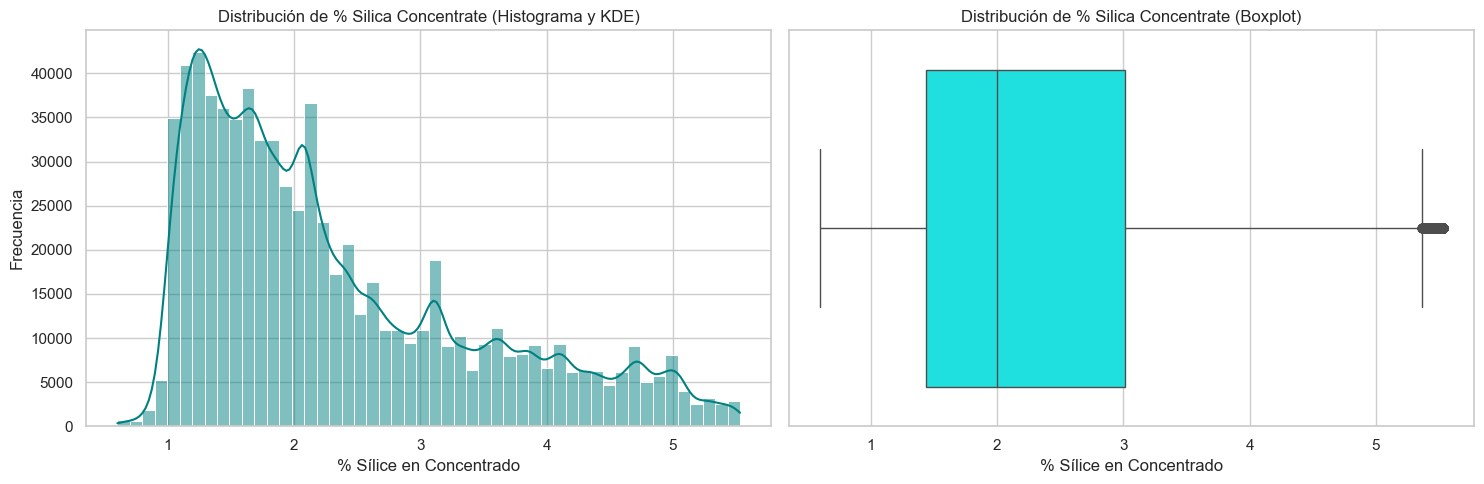

In [4]:
target_col = '% Silica Concentrate'

print("Estadísticas descriptivas de la variable objetivo:")
print(df[target_col].describe())

# Graficar la distribución
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histograma con KDE
sns.histplot(df[target_col], kde=True, bins=50, ax=axes[0], color='teal')
axes[0].set_title(f'Distribución de {target_col} (Histograma y KDE)')
axes[0].set_xlabel('% Sílice en Concentrado')
axes[0].set_ylabel('Frecuencia')

# Boxplot
sns.boxplot(x=df[target_col], ax=axes[1], color='cyan')
axes[1].set_title(f'Distribución de {target_col} (Boxplot)')
axes[1].set_xlabel('% Sílice en Concentrado')

plt.tight_layout()
plt.show()

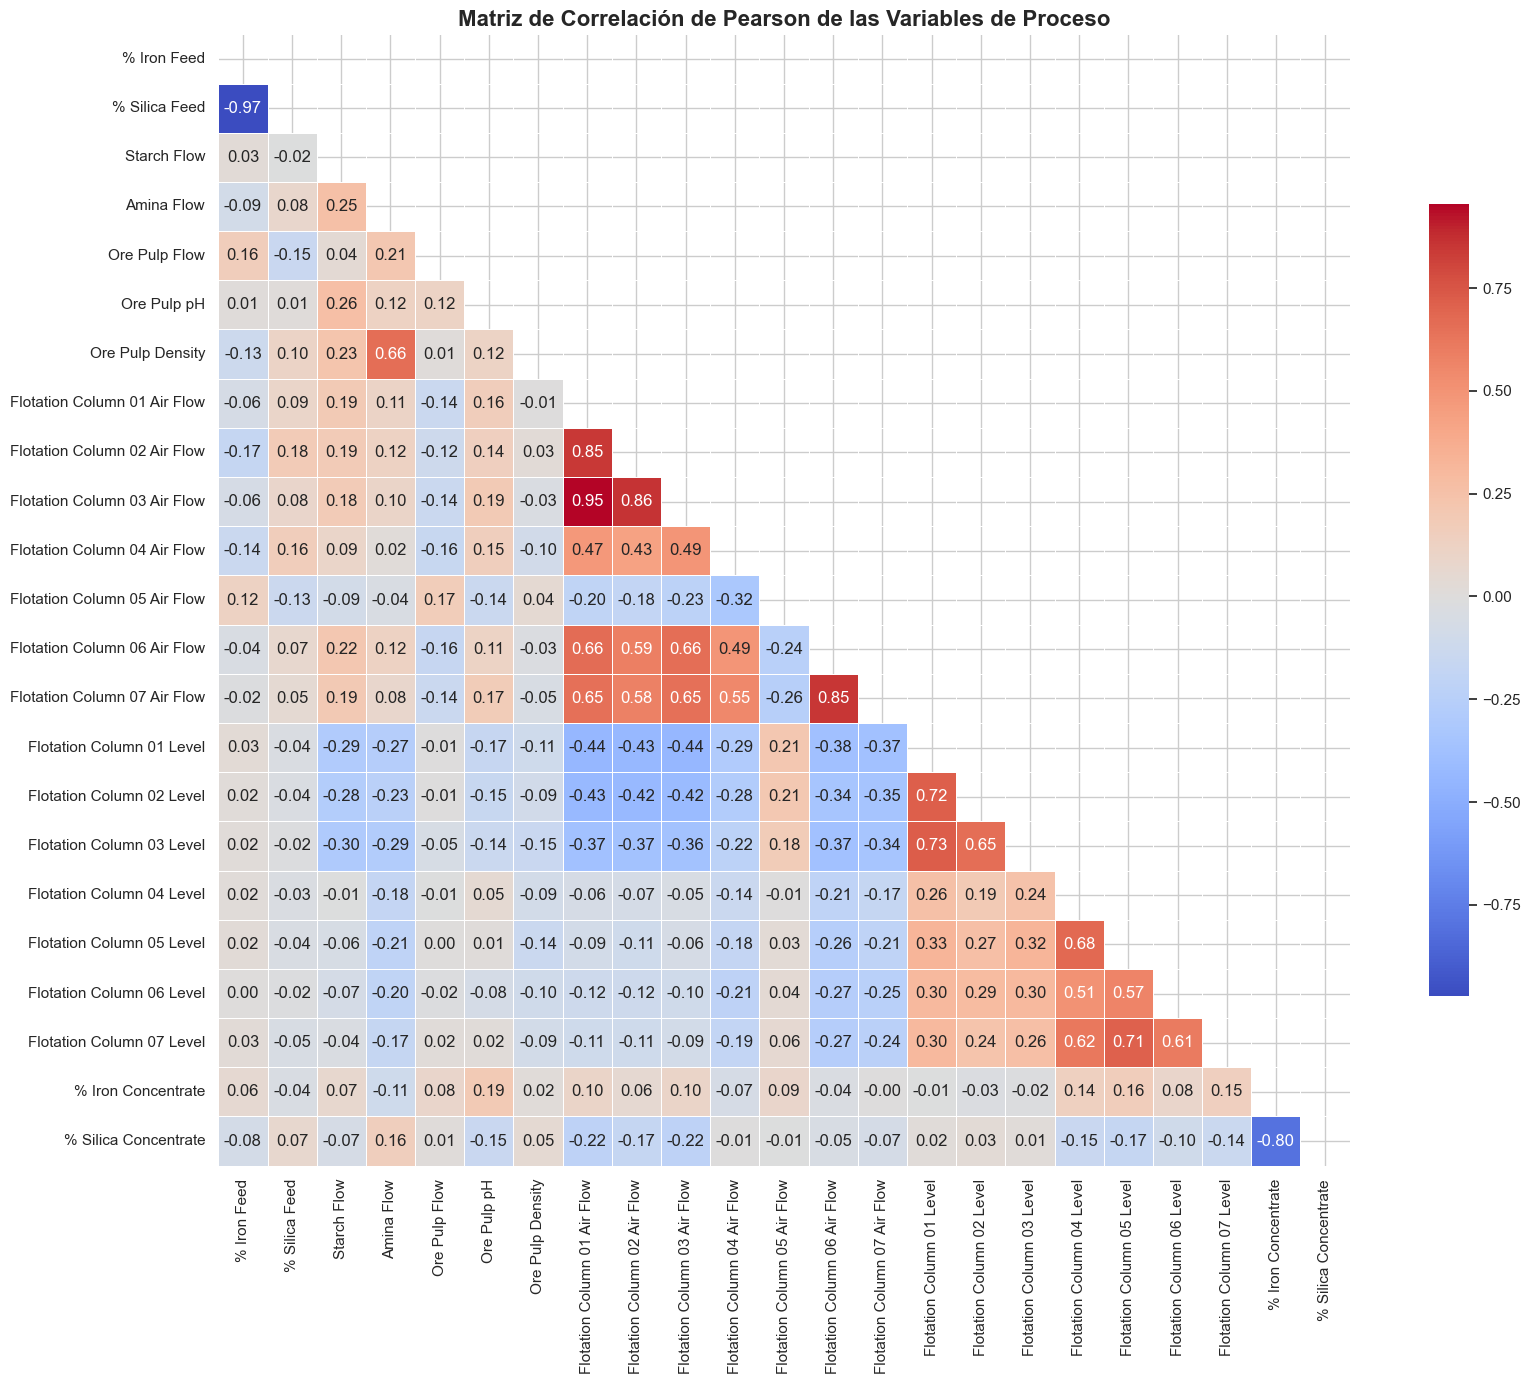

Correlación de las variables con la variable objetivo (% Silica Concentrate):
% Silica Concentrate            1.000000
Amina Flow                      0.156701
% Silica Feed                   0.072724
Ore Pulp Density                0.046984
Flotation Column 02 Level       0.030955
Flotation Column 01 Level       0.017217
Flotation Column 03 Level       0.014246
Ore Pulp Flow                   0.008222
Flotation Column 04 Air Flow   -0.005011
Flotation Column 05 Air Flow   -0.009293
Flotation Column 06 Air Flow   -0.049650
Starch Flow                    -0.066394
Flotation Column 07 Air Flow   -0.071776
% Iron Feed                    -0.077052
Flotation Column 06 Level      -0.102443
Flotation Column 07 Level      -0.141387
Ore Pulp pH                    -0.147739
Flotation Column 04 Level      -0.149456
Flotation Column 02 Air Flow   -0.167398
Flotation Column 05 Level      -0.169170
Flotation Column 03 Air Flow   -0.218891
Flotation Column 01 Air Flow   -0.219158
% Iron Concentrate  

In [5]:
# Calcular matriz de correlación
# Excluimos la columna date para el análisis de correlación lineal
numeric_cols = [col for col in df.columns if col != 'date']
corr_matrix = df[numeric_cols].corr()

# Graficar la matriz de correlación
plt.figure(figsize=(18, 14))
# Generamos una máscara para el triángulo superior (opcional, ayuda a la legibilidad)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', mask=mask, 
            square=True, linewidths=.5, cbar_kws={"shrink": .7})

plt.title("Matriz de Correlación de Pearson de las Variables de Proceso", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Resaltar la correlación de target leakage
print("Correlación de las variables con la variable objetivo (% Silica Concentrate):")
print(corr_matrix[target_col].sort_values(ascending=False))

Gráfico guardado exitosamente en: ../reports/figuras\silica_time_series.png


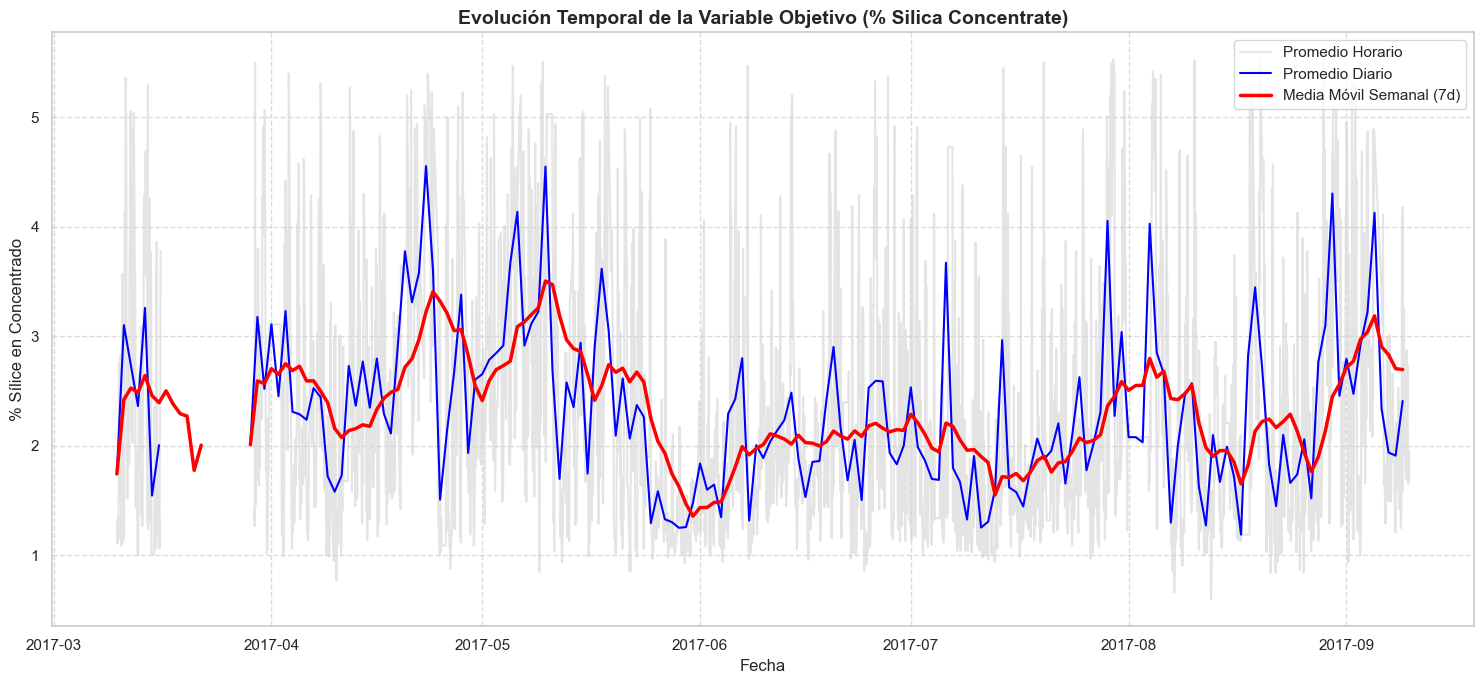

In [6]:
# Para graficar la serie temporal sin saturar el gráfico, resampleamos los datos
# Establecemos el índice temporal de forma temporal
df_ts = df.set_index('date')

# Resampleo por día (promedio diario)
df_daily = df_ts[target_col].resample('D').mean()
# Resampleo por hora (promedio horario)
df_hourly = df_ts[target_col].resample('h').mean()

# Graficar
plt.figure(figsize=(15, 7))

# Línea horaria con baja opacidad
plt.plot(df_hourly.index, df_hourly.values, color='lightgray', alpha=0.6, label='Promedio Horario')

# Línea diaria
plt.plot(df_daily.index, df_daily.values, color='blue', linewidth=1.5, label='Promedio Diario')

# Media móvil semanal (7 días) sobre la media diaria para capturar la tendencia de largo plazo
df_weekly_roll = df_daily.rolling(window=7, min_periods=1).mean()
plt.plot(df_weekly_roll.index, df_weekly_roll.values, color='red', linewidth=2.5, label='Media Móvil Semanal (7d)')

plt.title("Evolución Temporal de la Variable Objetivo (% Silica Concentrate)", fontsize=14, fontweight='bold')
plt.xlabel("Fecha")
plt.ylabel("% Sílice en Concentrado")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)

# Guardar figura
output_dir = '../reports/figuras'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'silica_time_series.png')

plt.tight_layout()
plt.savefig(output_path, dpi=300)
print(f"Gráfico guardado exitosamente en: {output_path}")
plt.show()